In [16]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional, Dropout
import matplotlib.pyplot as plt # Added for plotting training history later

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
# Loading the dataset
df = pd.read_csv('Customer_Sentiment.csv')

# Mapping 3 labels instead of 2
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

print(f"Data loaded with 3 classes. Shape: {df.shape}")

Data loaded with 3 classes. Shape: (25000, 14)


In [18]:
def clean_text(text):
    if isinstance(text, str):
        text = text.lower() # Lowercase
        text = re.sub(r'[^a-z0-9\s]', '', text) # Removing punctuation
        return text
    return ""

# Applying the cleaning function
df['clean_text'] = df['review_text'].apply(clean_text)

print("Text cleaning complete. Sample:")
print(df[['review_text', 'clean_text']].head())

Text cleaning complete. Sample:
                               review_text  \
0      very disappointed with the quality.   
1       fast delivery and great packaging.   
2      very disappointed with the quality.   
3  product stopped working after few days.   
4               neutral about the quality.   

                               clean_text  
0      very disappointed with the quality  
1       fast delivery and great packaging  
2      very disappointed with the quality  
3  product stopped working after few days  
4               neutral about the quality  


In [19]:
# Parameters
vocab_size = 5000 
embedding_dim = 64
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# Initializing and fit the tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['clean_text'])
word_index = tokenizer.word_index

# Converting text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Padding the sequences so they are all the same length
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Text tokenized. Vocabulary size: {len(word_index)}")
print(f"Shape of data tensor: {padded.shape}")

Text tokenized. Vocabulary size: 52
Shape of data tensor: (25000, 100)


In [20]:
from tensorflow.keras.utils import to_categorical

# Converting labels to one-hot encoding
y = to_categorical(df['label'], num_classes=3)


X_train, X_test, y_train, y_test = train_test_split(padded, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} reviews")
print(f"Testing on {len(X_test)} reviews")

Training on 20000 reviews
Testing on 5000 reviews


In [21]:
model = Sequential()
# Building the model
model.add(Embedding(vocab_size, embedding_dim, input_length=max_length))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu')) 
model.add(Dense(3, activation='softmax'))
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam', 
    metrics=['accuracy']
)

c:\Users\Ansh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
num_epochs = 5
history = model.fit(
    X_train, 
    y_train, 
    epochs=num_epochs, 
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.9671 - loss: 0.0841 - val_accuracy: 1.0000 - val_loss: 1.2479e-05
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 1.0000 - loss: 9.1936e-05 - val_accuracy: 1.0000 - val_loss: 2.1873e-06
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 1.0000 - loss: 3.6338e-05 - val_accuracy: 1.0000 - val_loss: 3.4792e-07
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 1.0000 - loss: 1.8635e-05 - val_accuracy: 1.0000 - val_loss: 1.2021e-07
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 1.0000 - loss: 9.9312e-06 - val_accuracy: 1.0000 - val_loss: 5.3596e-08


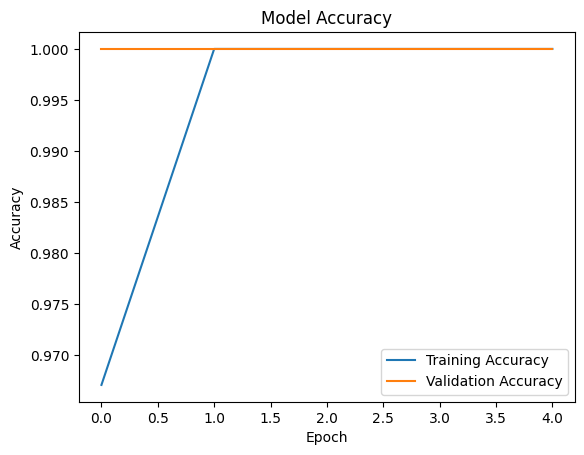

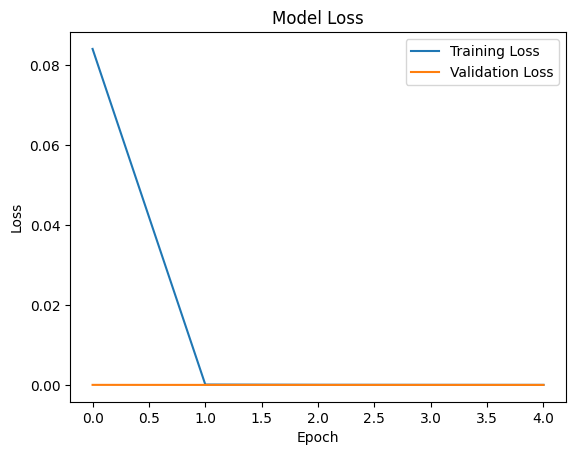

In [23]:
# Ploting accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Ploting loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [24]:
def predict_sentiment(text):
    cleaned_text = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
    
    # Predict returns an array like [0.1, 0.8, 0.1]
    prediction = model.predict(padded)
    class_idx = np.argmax(prediction)
    mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}
    label = mapping[class_idx]
    confidence = prediction[0][class_idx]
    
    return f"{label} (Confidence: {confidence:.2f})"
# --- Test Cases ---
print("\n--- Final Test ---")
print(f"Review: 'The food was average but delivery was on time '")
print(f"Prediction: {predict_sentiment('The food was not so good but delivery was on time ')}\n")

print(f"Review: 'product was great'")
print(f"Prediction: {predict_sentiment('product was great')}\n")

print(f"Review: 'the food delivery was not on time'")
print(f"Prediction: {predict_sentiment('the food delivery was not on time')}")


--- Final Test ---
Review: 'The food was average but delivery was on time '
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
Prediction: Neutral (Confidence: 0.99)

Review: 'product was great'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: Positive (Confidence: 0.93)

Review: 'the food delivery was not on time'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction: Negative (Confidence: 1.00)


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1997
     Neutral       1.00      1.00      1.00      1021
    Positive       1.00      1.00      1.00      1982

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



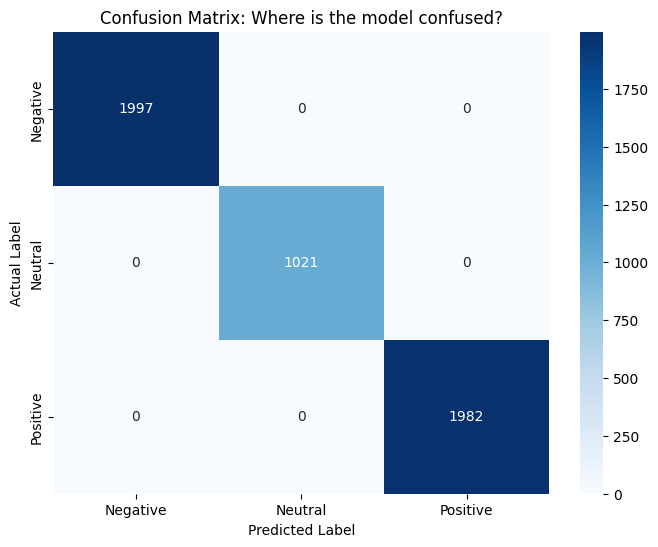

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Getting model predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Printing Classification Report
# This shows Precision, Recall, and F1-Score for each class
names = ['Negative', 'Neutral', 'Positive']
print(classification_report(y_true, y_pred_classes, target_names=names))

# 3. Plotting Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=names, yticklabels=names)
plt.title('Confusion Matrix: Where is the model confused?')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

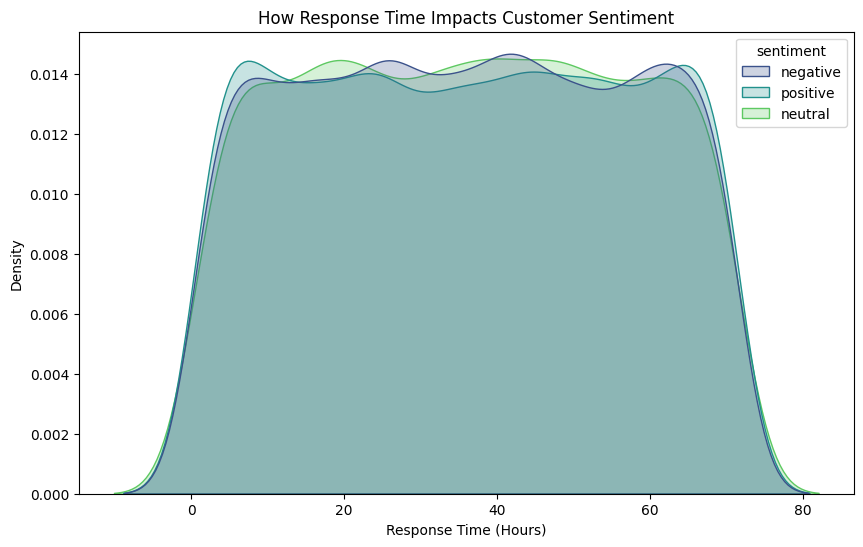

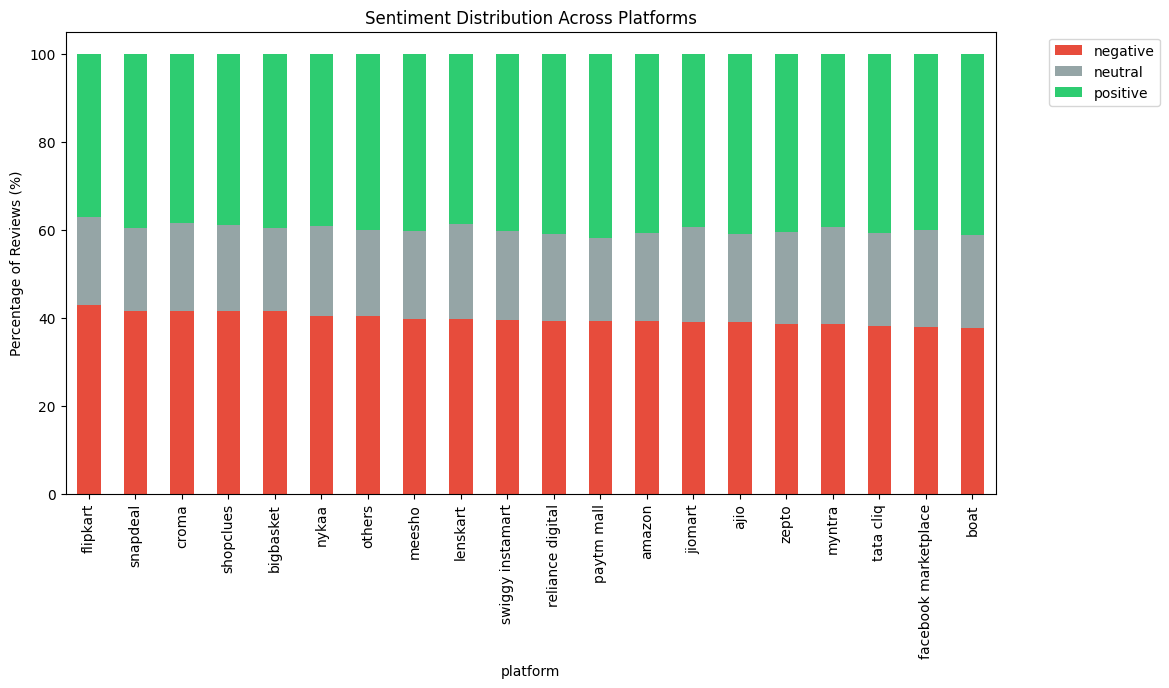

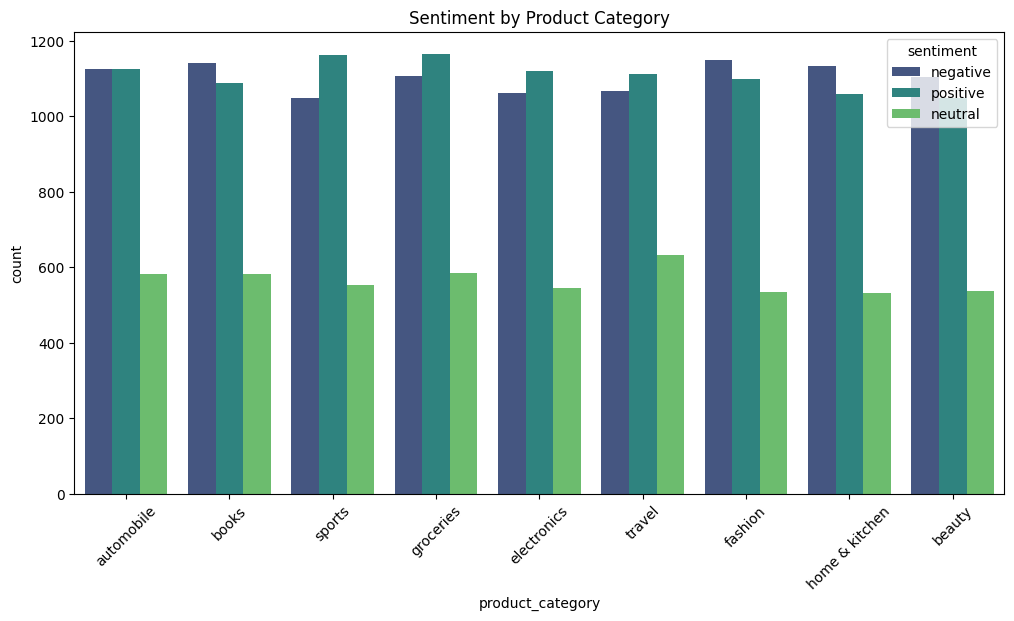

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The "Response Time" Threshold
# This shows how waiting too long directly causes negative sentiment
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='response_time_hours', hue='sentiment', fill=True, common_norm=False, palette='viridis')
plt.title('How Response Time Impacts Customer Sentiment')
plt.xlabel('Response Time (Hours)')
plt.ylabel('Density')
plt.show()

# 2. Platform Performance
# Identifing which platforms are struggling with customer satisfaction
platform_sentiment = pd.crosstab(df['platform'], df['sentiment'], normalize='index') * 100
platform_sentiment.sort_values(by='negative', ascending=False).plot(kind='bar', stacked=True, figsize=(12, 6), color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution Across Platforms')
plt.ylabel('Percentage of Reviews (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. Categorical Analysis
# Which product categories need immediate attention?
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='product_category', hue='sentiment', palette='viridis')
plt.title('Sentiment by Product Category')
plt.xticks(rotation=45)
plt.show()

In [27]:

# Here, we use a pre-trained model to see how it compares to our custom LSTM

from transformers import pipeline

# Loading a pre-trained sentiment transformer
# This model has already 'read' millions of sentences
transformer_model = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

def test_transformers(text):
    result = transformer_model(text)[0]
    # Mapping for this specific model: 0 -> Negative, 1 -> Neutral, 2 -> Positive
    labels = {0: "Negative", 1: "Neutral", 2: "Positive"}
    label_id = int(result['label'].split('_')[1])
    return f"Sentiment: {labels[label_id]} | Confidence: {result['score']:.2%}"

# Testing it on a tricky review
sample = "The the food was average but delivery was on time "
print(f"Review: {sample}")
print(f"Transformer Result: {test_transformers(sample)}")

Device set to use cpu


Review: The the food was average but delivery was on time 
Transformer Result: Sentiment: Neutral | Confidence: 55.55%
